# Testing Distance Computations

This notebook tests the distance computation implementations from the `distances.py` module. We'll test:
1. Euclidean distances between points
2. Voltage-based distances
3. Graph-based distances (k-connectivity)

First, setting up our test environment and import required libraries.

In [15]:
# Add parent directory to Python path to import Utilities
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse.csgraph import connected_components
from clean_code.Utilities.distances import compute_distances
from clean_code.setofpoints import SetOfPoints

# Set random seed for reproducibility
np.random.seed(42)

## Create Test Data Generation Functions

We'll create functions to generate synthetic clustered data for testing our distance computations. 
These functions will help us create controlled test cases with known properties.

In [16]:
def create_test_clusters(n_clusters=4, points_per_cluster=4, spread=0.2, seed=42):
    """Create synthetic clustered data for testing."""
    np.random.seed(seed)
    centers = np.random.rand(n_clusters, 2)  # Random cluster centers
    clusters = []
    labels = []
    
    for i, center in enumerate(centers):
        cluster_points = spread * np.random.rand(points_per_cluster, 2) + center
        clusters.append(cluster_points)
        labels.extend([i] * points_per_cluster)
    
    return np.vstack(clusters), np.array(labels)

# Create test data
points, labels = create_test_clusters()
print(f"Generated {len(points)} points in {len(np.unique(labels))} clusters")

# Create synthetic voltage data
voltages = np.random.rand(len(points), 5)  # 5 voltage dimensions
print(f"Generated voltage data with shape: {voltages.shape}")

Generated 16 points in 4 clusters
Generated voltage data with shape: (16, 5)


## Define Visualization Functions

Now we'll create functions to visualize our test data and the resulting distance matrices.
This will help us verify that our distance computations are working as expected.

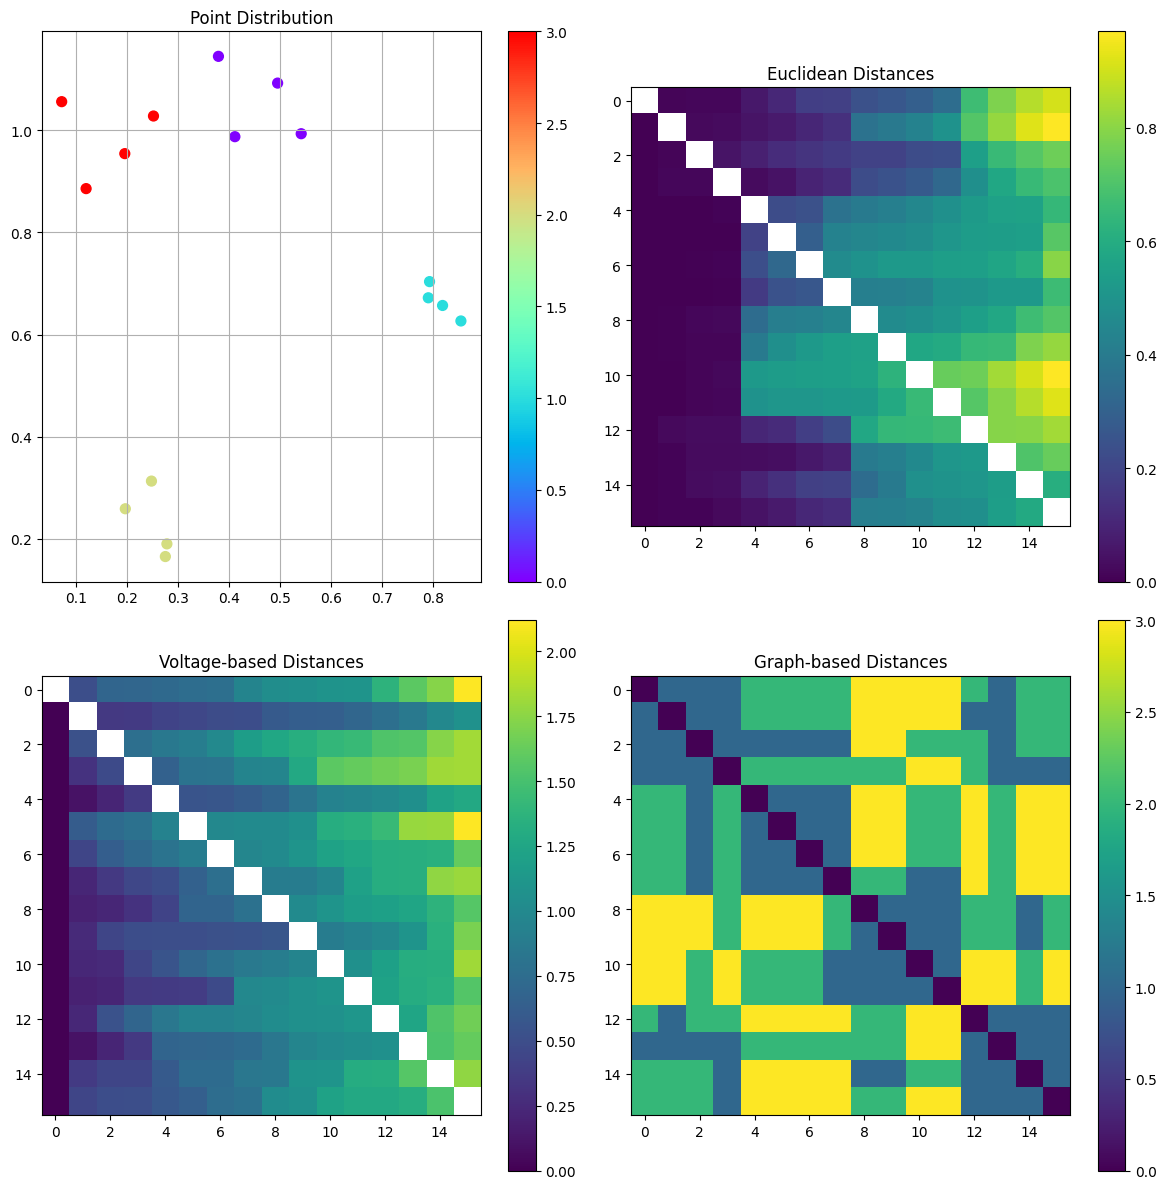

In [17]:
def visualize_distances(points, D1, D2, D3, labels=None):
    """Visualize the three distance matrices and the point distribution."""
    fig, axes = plt.subplots(2, 2, figsize=(12, 12))
    
    # Plot points
    scatter = axes[0, 0].scatter(points[:, 0], points[:, 1], 
                                c=labels if labels is not None else 'blue',
                                s=50, cmap='rainbow')
    if labels is not None:
        plt.colorbar(scatter, ax=axes[0, 0])
    axes[0, 0].set_title('Point Distribution')
    axes[0, 0].grid(True)
    
    # Plot distance matrices
    im1 = axes[0, 1].imshow(D1, cmap='viridis')
    axes[0, 1].set_title('Euclidean Distances')
    plt.colorbar(im1, ax=axes[0, 1])
    
    im2 = axes[1, 0].imshow(D2, cmap='viridis')
    axes[1, 0].set_title('Voltage-based Distances')
    plt.colorbar(im2, ax=axes[1, 0])
    
    im3 = axes[1, 1].imshow(D3, cmap='viridis')
    axes[1, 1].set_title('Graph-based Distances')
    plt.colorbar(im3, ax=axes[1, 1])
    
    plt.tight_layout()
    return fig

# Create point set and compute distances
point_set = SetOfPoints(points=points)
D1, D2, D3 = compute_distances(point_set, voltages)

# Visualize results
fig = visualize_distances(points, D1, D2, D3, labels)
plt.show()

## Basic Distance Tests
Test the basic properties that our distance matrices should satisfy:
1. Symmetry
2. Non-negativity
3. Diagonal properties
4. Triangle inequality

In [18]:
# Test 1: Check matrix shapes
print("Matrix shapes:")
print(f"D1 (Euclidean): {D1.shape}")
print(f"D2 (Voltage): {D2.shape}")
print(f"D3 (Graph): {D3.shape}")
assert D1.shape == D2.shape == D3.shape, "All distance matrices should have the same shape"

# Test 2: Check symmetry
print("\nChecking symmetry...")
print(f"D1 symmetric: {np.allclose(D1, D1.T)}")
print(f"D2 symmetric: {np.allclose(D2, D2.T)}")
print(f"D3 symmetric: {np.allclose(D3, D3.T)}")

# Test 3: Check diagonal values
print("\nChecking diagonal values...")
print(f"D1 diagonal all -inf: {np.all(np.diagonal(D1) == -np.inf)}")
print(f"D2 diagonal all -inf: {np.all(np.diagonal(D2) == -np.inf)}")
print(f"D3 diagonal all zero: {np.all(np.diagonal(D3) == 0)}")

# Test 4: Check non-negativity (excluding diagonal)
mask = ~np.eye(len(points), dtype=bool)  # Mask to exclude diagonal
print("\nChecking non-negativity (excluding diagonal)...")
print(f"D1 non-negative: {np.all(D1[mask] >= 0)}")
print(f"D2 non-negative: {np.all(D2[mask] >= 0)}")
print(f"D3 non-negative: {np.all(D3[mask] >= 0)}")

Matrix shapes:
D1 (Euclidean): (16, 16)
D2 (Voltage): (16, 16)
D3 (Graph): (16, 16)

Checking symmetry...
D1 symmetric: False
D2 symmetric: False
D3 symmetric: True

Checking diagonal values...
D1 diagonal all -inf: True
D2 diagonal all -inf: True
D3 diagonal all zero: True

Checking non-negativity (excluding diagonal)...
D1 non-negative: True
D2 non-negative: True
D3 non-negative: True


## Edge Cases

Now let's test some edge cases:
1. Single point
2. Two points
3. Disconnected points

In [ ]:
# Test single point
print("Testing single point...")
try:
    single_point = np.array([[1.0, 1.0]])
    point_set = SetOfPoints(points=single_point)
    voltages = np.array([[1.0]])
    D1, D2, D3 = compute_distances(point_set, voltages)
    print("Warning: Single point case should raise an error")
except ValueError as e:
    print("Correctly caught error for single point:", str(e))

# Test two points
print("\nTesting two points...")
two_points = np.array([[0.0, 0.0], [1.0, 1.0]])
point_set = SetOfPoints(points=two_points)
voltages = np.array([[0.0], [1.0]])
D1, D2, D3 = compute_distances(point_set, voltages)
print(f"Two points distance matrices shapes: {D1.shape}")
print("Euclidean distance between points:", D1[0,1])

# Test disconnected points
print("\nTesting disconnected points...")
cluster1 = np.random.rand(5, 2)
cluster2 = np.random.rand(5, 2) + 3  # Offset to create separation
points = np.vstack([cluster1, cluster2])
point_set = SetOfPoints(points=points)
voltages = np.random.rand(len(points), 3)

D1, D2, D3 = compute_distances(point_set, voltages)
adjacency = D3 < np.inf
n_components, labels = connected_components(adjacency)
print(f"Number of connected components: {n_components}")

# Visualize disconnected points
fig = visualize_distances(points, D1, D2, D3, labels)
plt.show()

## Connected Components Analysis

Analyze the graph-based distances in more detail:
1. Number of connected components
2. Component sizes
3. Intra- vs inter-component distances

Number of connected components: 4

Component sizes:
Component 0: 5 points
Component 1: 5 points
Component 2: 5 points
Component 3: 5 points

Distance statistics:
Average distance within components: 1.00
Average distance between components: inf


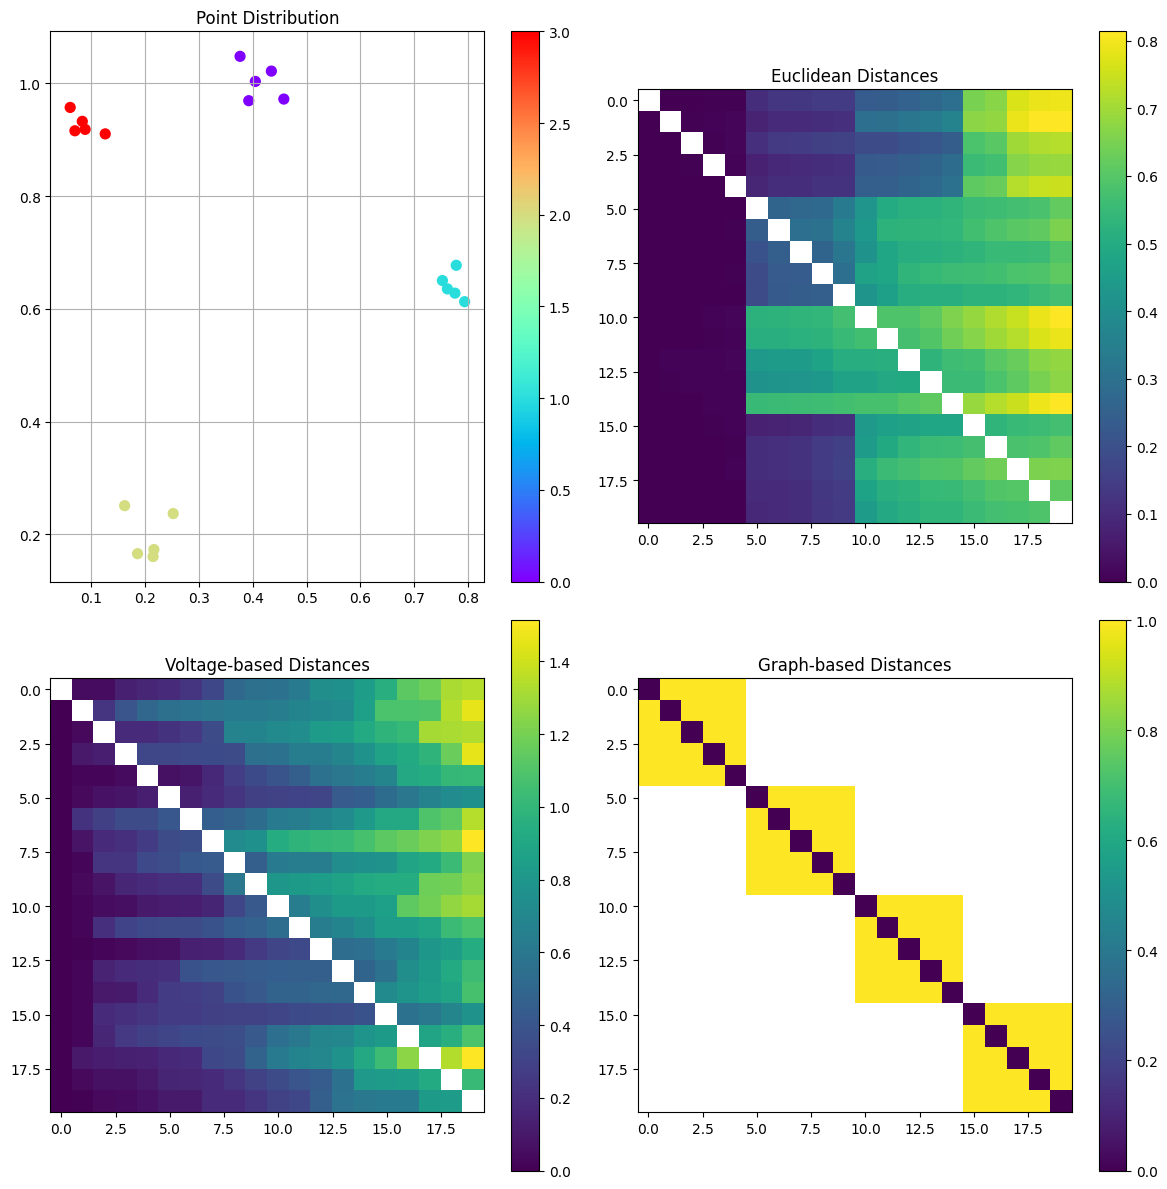

In [19]:
# Create test data with multiple components
points, true_labels = create_test_clusters(n_clusters=4, points_per_cluster=5, spread=0.1)
point_set = SetOfPoints(points=points)
voltages = np.random.rand(len(points), 3)

# Compute distances
D1, D2, D3 = compute_distances(point_set, voltages)

# Analyze graph connectivity
adjacency = D3 < np.inf
n_components, labels = connected_components(adjacency)

print(f"Number of connected components: {n_components}")

# Analyze component sizes
unique_labels, counts = np.unique(labels, return_counts=True)
print("\nComponent sizes:")
for label, count in zip(unique_labels, counts):
    print(f"Component {label}: {count} points")

# Calculate average distances within and between components
within_distances = []
between_distances = []

for i in range(len(points)):
    for j in range(i+1, len(points)):
        if labels[i] == labels[j]:
            within_distances.append(D3[i,j])
        else:
            between_distances.append(D3[i,j])

print("\nDistance statistics:")
print(f"Average distance within components: {np.mean(within_distances):.2f}")
print(f"Average distance between components: {np.mean(between_distances):.2f}")

# Visualize results with component labels
fig = visualize_distances(points, D1, D2, D3, labels)
plt.show()